In [40]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from rnn_models import RNN
from plots import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
LAG = 12

## Read in and window data

In [3]:
flights = pd.read_csv("./Pre-processed datasets/flights_final.csv", index_col=0, parse_dates=True)

In [4]:
original_passengers = pd.read_csv("Datasets/airline-passengers.csv", index_col=0, parse_dates=True)["Passengers"]
log_passengers = np.log(original_passengers)
target_dates = flights.index[LAG:]          # the month each y belongs to

def to_passengers(z_pred, dates):
    pos = log_passengers.index.get_indexer(dates)
    log_pred = z_pred + log_passengers.iloc[pos-1].values + log_passengers.iloc[pos-12].values - log_passengers.iloc[pos-13].values
    return np.exp(log_pred)

In [5]:
# Turn the series into windows.
series = flights["Passengers"].to_numpy(dtype="float32")
windows = np.stack([series[i:i + LAG] for i in range(len(series) - LAG)])
y = series[LAG:]

In [6]:
# base_t for each target month, stored as column 0 of X.
pos = log_passengers.index.get_indexer(flights.index[LAG:])
base = log_passengers.values[pos - 1] + log_passengers.values[pos - 12] - log_passengers.values[pos - 13]
X = np.column_stack([base, windows])      # shape (119, 1 + MAX_LAG)

# Keep the final 12 months out of the grid search entirely, as a final test.
X_dev, y_dev = X[:-12], y[:-12]
X_test, y_test = X[-12:], y[-12:]

## Custom scoring functions

In [7]:
def passenger_rmse(estimator, X, y):
    b = X[:, 0]
    pred   = np.exp(estimator.predict(X) + b)
    actual = np.exp(y + b)
    return -np.sqrt(np.mean((pred - actual) ** 2))

def passenger_mape(estimator, X, y):
    b = X[:, 0]
    pred   = np.exp(estimator.predict(X) + b)
    actual = np.exp(y + b)
    return -100 * np.mean(np.abs(pred - actual) / actual)

## Elman: grid search using cross validation

In [9]:
# 5 iterations.
cv = TimeSeriesSplit(n_splits=5, test_size=12)

# Hyperparameters to search over.
param_grid_elman = {
    "lags": [12],
    "units": [4, 8, 16],
    "lr": [0.01],
    "epochs": [200, 500],
    "l2": [1e-4, 1e-3, 1e-2]
}

# Run Grid Search
grid_search_elman = GridSearchCV(
    estimator=RNN(arch="elman"),
    param_grid=param_grid_elman,
    cv=cv,
    scoring={"rmse": passenger_rmse,"mape": passenger_mape},
    refit="rmse",
    n_jobs=1,
    verbose=1
)
grid_search_elman.fit(X_dev, y_dev)

# Retrieve the best model and parameters.
best_model_elman = grid_search_elman.best_estimator_
best_params_elman = grid_search_elman.best_params_
test_mse_elman = np.mean((best_model_elman.predict(X_test) - y_test) ** 2)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


In [45]:
best_model

,epochs,200
,l2,0.01
,arch,'elman'
,lags,12
,units,8
,lr,0.01
,n_banks,4
,seed,0
Name,Type,Value
model_,Functional,"<Functional n...3, built=True>"
mu_,float32,np.float32(-0.00044857548)


## Jordan: grid search using cross validation

In [11]:
# 5 iterations.
cv = TimeSeriesSplit(n_splits=5, test_size=12)

# Hyperparameters to search over.
param_grid_jordan = {
    "lags": [12],
    "units": [4, 8, 16],
    "lr": [0.01],
    "epochs": [200, 500],
    "l2": [1e-4, 1e-3, 1e-2]
}

# Run Grid Search
grid_search_jordan = GridSearchCV(
    estimator=RNN(arch="jordan"),
    param_grid=param_grid_jordan,
    cv=cv,
    scoring={"rmse": passenger_rmse,"mape": passenger_mape},
    refit="rmse",
    n_jobs=1,
    verbose=1
)
grid_search_jordan.fit(X_dev, y_dev)

# Retrieve the best model and parameters.
best_model_jordan = grid_search_jordan.best_estimator_
best_params_jordan = grid_search_jordan.best_params_
test_mse_jordan = np.mean((best_model_jordan.predict(X_test) - y_test) ** 2)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


In [44]:
best_model_jordan

,arch,'jordan'
,units,16
,epochs,200
,l2,0.01
,lags,12
,lr,0.01
,n_banks,4
,seed,0
Name,Type,Value
model_,Functional,"<Functional n...4, built=True>"
mu_,float32,np.float32(-0.00044857548)


## MRNN: grid search using cross validation

In [24]:
# 5 iterations.
cv = TimeSeriesSplit(n_splits=5, test_size=12)

# Hyperparameters to search over.
param_grid_mrnn = {
    "lags": [12],
    "units": [4, 8, 16],
    "lr": [0.01],
    "epochs": [200, 500],
    "l2": [1e-4, 1e-3, 1e-2]
}

# Run Grid Search
grid_search_mrnn = GridSearchCV(
    estimator=RNN(arch="mrnn"),
    param_grid=param_grid_mrnn,
    cv=cv,
    scoring={"rmse": passenger_rmse,"mape": passenger_mape},
    refit="rmse",
    n_jobs=1,
    verbose=1
)
grid_search_mrnn.fit(X_dev, y_dev)

# Retrieve the best model and parameters.
best_model_mrnn = grid_search_mrnn.best_estimator_
best_params_mrnn = grid_search_mrnn.best_params_
test_mse_mrnn = np.mean((best_model_mrnn.predict(X_test) - y_test) ** 2)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


In [43]:
best_model_mrnn

,arch,'mrnn'
,units,4
,epochs,200
,l2,0.0001
,lags,12
,lr,0.01
,n_banks,4
,seed,0
Name,Type,Value
model_,Functional,"<Functional n...6, built=True>"
mu_,float32,np.float32(-0.00044857548)


In [ ]:
print(f"Test MSE Elman: {test_mse}")
print(f"Test MSE Jordan: {test_mse_jordan}")
print(f"Test MSE Elman: {test_mse_mrnn}")

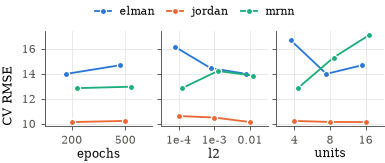

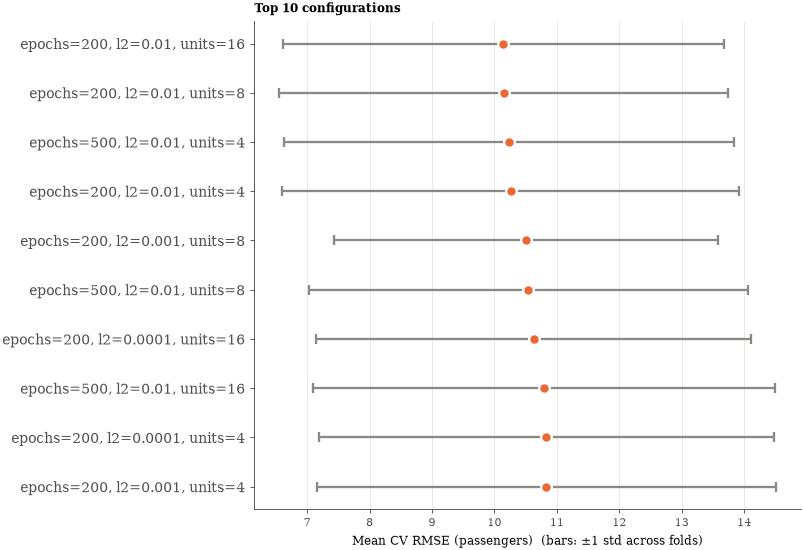

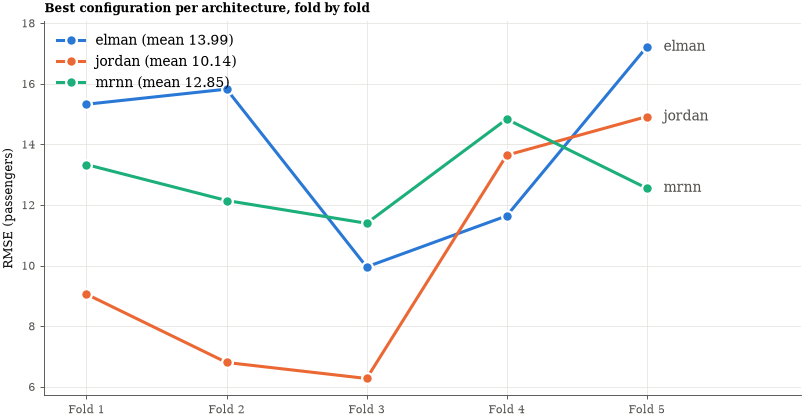

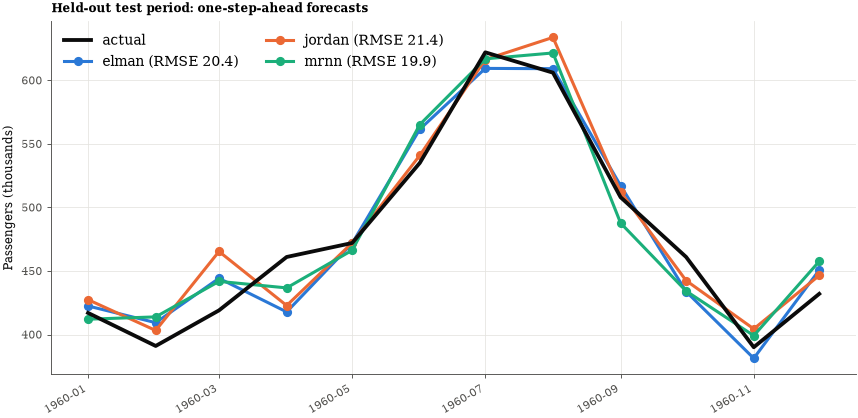

In [39]:
searches = {"elman": grid_search, "jordan": grid_search_jordan, "mrnn": grid_search_mrnn}

ieee_style()

fig = plot_param_effects_all(searches, ncols=3, width=IEEE_COLUMN, title=False)
fig.savefig("./Plots/Flights/param_effects.pdf")
fig = plot_top_configs(searches["jordan"], n=10)
fig.savefig("./Plots/Flights/top_configs_jordan.pdf")
fig = plot_fold_comparison(searches)
fig.savefig("./Plots/Flights/fold_comparison.pdf")
fig = plot_test_forecast(searches, X_test, y_test, dates=flights.index[LAG:][-12:])
fig.savefig("./Plots/Flights/test_forecast.pdf")

## Cross-validation function

In [11]:
def cv_scores(architecture, units=8, learning_rate=0.01, epochs=300, n_splits=5, test_size=12, seed=0, **kw):
    cv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    scores = []
    for train_index, test_index in cv.split(X):
        set_random_seed(seed)

        # scale using the training fold only.
        mean, sd = y[train_index].mean(), y[train_index].std()
        X_train, y_train = (X[train_index] - mean)/sd, (y[train_index] - mean)/sd
        X_test = (X[test_index] - mean)/sd

        # Build and fit model.
        model = build_model(architecture, lags=X.shape[1], units=units, lr=learning_rate, **kw)
        model.fit(X_train, y_train, epochs=epochs, batch_size=len(y_train), verbose=0)

        # Test the model.
        pred = model.predict(X_test, verbose=0).ravel()*sd + mean

        # Reverse pre-preocessing steps before calculating errors.
        dates = target_dates[test_index]
        pred_pass = to_passengers(pred, dates)
        actual = original_passengers.loc[dates].values
        scores.append(np.sqrt(np.mean((pred_pass - actual) ** 2)))   # RMSE in passengers
        
    return scores